# Vibration Fatigue Analysis: ydir.xlsx
## Aluminum 6061-T6 | FLife Spectral Methods

Fatigue life estimation using spectral domain analysis of stress PSD data.
Material: Aluminum 6061-T6 | C = 1.8e+22 (MPa^k) | k = 7.3

## 1. Setup & Input Configuration

In [2]:
# Initialize imports and setup
import os
import sys
sys.path.insert(0, os.path.realpath('__file__'))

import matplotlib.pyplot as plt
%matplotlib inline

import FLife
import numpy as np
import pandas as pd
from ipywidgets import widgets, HBox, Output
from IPython.display import display, HTML

# For compatibility with different numpy versions
if np.__version__>='2.0.0':
    trapezoid = np.trapezoid
else:
    trapezoid = np.trapz

print('✓ All required libraries imported successfully')
print('✓ GUI framework initialized')

✓ All required libraries imported successfully
✓ GUI framework initialized


In [3]:
# ==================== INTERACTIVE GUI SECTION ====================

# Define Data Folder
data_folder = r'C:\Users\girib\OneDrive\Desktop\MY WORK\Trading\Pine_Scripts\Weekly_swing\FLife\data\vibration_data'

# Get list of Excel files in data folder
import glob
excel_files = glob.glob(os.path.join(data_folder, '*.xlsx')) + glob.glob(os.path.join(data_folder, '*.xls'))
excel_filenames = [os.path.basename(f) for f in excel_files]

# Create GUI Components
style_dict = {'description_width': '150px'}

# File Selector Dropdown
file_selector = widgets.Dropdown(
    options=excel_filenames if excel_filenames else ['No files found'],
    value=excel_filenames[0] if excel_filenames else 'No files found',
    description='Excel File:',
    style=style_dict,
    layout=widgets.Layout(width='400px')
)

# Number of Rows
num_rows_input = widgets.IntText(
    value=0,
    description='Num Rows:',
    style=style_dict,
    layout=widgets.Layout(width='280px')
)

# Frequency Range
freq_min_input = widgets.FloatText(
    value=0.0,
    description='Freq Min [Hz]:',
    style=style_dict,
    layout=widgets.Layout(width='280px')
)

freq_max_input = widgets.FloatText(
    value=0.0,
    description='Freq Max [Hz]:',
    style=style_dict,
    layout=widgets.Layout(width='280px')
)

# Test Duration
test_duration_input = widgets.FloatSlider(
    value=1.0,
    min=0.1,
    max=100.0,
    step=0.1,
    description='Test Duration [hours]:',
    style=style_dict,
    layout=widgets.Layout(width='400px')
)

# Material Database with Standard Values
materials_db = {
    'Aluminum Alloy 6061': {
        'name': 'Aluminum Alloy 6061',
        'C': 1.8e+22,
        'k': 7.3,
        'description': 'Aluminum Alloy 6061 - Standard wrought aluminum'
    },
    'Copper C12200': {
        'name': 'Copper C12200',
        'C': 8.5e+20,
        'k': 7.0,
        'description': 'Copper C12200 - High conductivity copper'
    }
}

# Material Selector Dropdown
material_selector = widgets.Dropdown(
    options=list(materials_db.keys()),
    value='Aluminum Alloy 6061',
    description='Material:',
    style=style_dict,
    layout=widgets.Layout(width='400px')
)

# Manual C and k Input Fields
c_input = widgets.FloatText(
    value=1.8e+22,
    description='C (MPa^k):',
    style=style_dict,
    layout=widgets.Layout(width='280px'),
    step=1e20,
    tooltip='Fatigue coefficient C has units MPa^k (MPa raised to power k). Example: if k=7.3, then C is in MPa^7.3'
)

k_input = widgets.FloatText(
    value=7.3,
    description='k (Slope):',
    style=style_dict,
    layout=widgets.Layout(width='280px'),
    step=0.1,
    tooltip='Fatigue exponent k (dimensionless). Typical range: 3-10. Used in S-N curve: S = C × N^(-1/k)'
)

# Material Info Display
material_info = widgets.HTML(
    value=f'<b>Aluminum Alloy 6061</b><br/>C = 1.8e+22 MPa^k<br/>k = 7.3',
    layout=widgets.Layout(width='500px', border='1px solid #ccc', padding='10px')
)

# Load Data Button
load_button = widgets.Button(
    description='Load & Process Data',
    button_style='success',
    tooltip='Load Excel file and process data',
    layout=widgets.Layout(width='200px', height='40px')
)

# Output Area
output_area = Output()

# Display GUI Layout
display(HTML('<h3>📊 VIBRATION FATIGUE ANALYSIS - INPUT CONFIGURATION</h3>'))
display(HTML('<hr style="margin: 20px 0;">'))

display(HTML('<h4>1️⃣ Excel File Selection</h4>'))
display(HTML(f'<p style="color: #666; font-size: 0.9em;">📁 Location: {data_folder}<br/>Expected format: Column 1 = Frequency [Hz], Column 2 = Stress Response [MPa²/Hz]</p>'))
display(file_selector)

display(HTML('<h4>2️⃣ Data Configuration</h4>'))
display(HBox([num_rows_input, widgets.HTML('<p style="margin: 8px 0 0 10px; color: #888; font-size: 0.85em;">Leave as 0 to use all rows</p>')]))
display(HBox([freq_min_input, freq_max_input]))

display(HTML('<h4>3️⃣ Test Parameters</h4>'))
display(test_duration_input)

display(HTML('<h4>4️⃣ Material Selection</h4>'))
display(material_selector)
display(material_info)

display(HTML('<h4>5️⃣ Material Properties (Auto-populated - Editable)</h4>'))
display(HTML('<p style="color: #666; font-size: 0.9em; margin: 10px 0;">💡 Select a material or manually adjust C and K values:</p>'))
display(HTML('<p style="color: #888; font-size: 0.85em; margin: 0 0 5px 0;"><i>Note: C has units MPa^k (MPa raised to power k). For k=7.3, C is in MPa^7.3. S-N curve: S = C × N^(-1/k)</i></p>'))
display(HBox([c_input, k_input]))

display(HTML('<br/>'))
display(load_button)
display(HTML('<hr style="margin: 20px 0;">'))
display(output_area)

print('✓ Interactive GUI Created - Ready for Input!')

# Function to update material info and C/k values
def update_material_info(change):
    selected = change['new']
    mat_data = materials_db[selected]
    material_info.value = f'<b>{mat_data["name"]}</b><br/>C = {mat_data["C"]:.2e} MPa^k<br/>k = {mat_data["k"]}'
    # Auto-populate C and k input fields when material is selected
    c_input.value = mat_data['C']
    k_input.value = mat_data['k']

material_selector.observe(update_material_info, names='value')

# Define the button click handler function
def load_and_process_data(button):
    global freq, psd, psd_3sigma, file_basename, test_duration_seconds, C, k, sd, sd_3sigma
    global results_1sigma, results_3sigma, safety_factors_1sigma, safety_factors_3sigma
    global damage_1sigma, damage_3sigma, max_damage_1sigma, max_damage_3sigma
    
    with output_area:
        output_area.clear_output()
        
        try:
            # Validate inputs
            if file_selector.value == 'No files found':
                print('❌ ERROR: No Excel files found in the data folder!')
                print(f'📁 Path: {data_folder}')
                return
            
            # Get filename and full path
            filename = file_selector.value
            file_path = os.path.join(data_folder, filename)
            
            # Read Excel directly from disk
            df = pd.read_excel(file_path)
            
            file_basename = os.path.splitext(filename)[0]
            
            # Extract data from columns
            # Column 1 = Frequency [Hz]
            # Column 2 = Stress Response [MPa²/Hz] - 1 SIGMA
            
            num_rows = int(num_rows_input.value) if num_rows_input.value > 0 else len(df)
            
            freq = df.iloc[0:num_rows, 0].values.astype(float)  # Column 1: Frequency
            psd = df.iloc[0:num_rows, 1].values.astype(float)   # Column 2: 1-sigma PSD
            
            # Calculate 3-sigma PSD (PSD scales as sigma^2, so 3-sigma = 9 × 1-sigma)
            psd_3sigma = psd * 9.0
            
            # Update frequency range displays
            freq_min_input.value = freq[0]
            freq_max_input.value = freq[-1]
            
            print(f'✅ File loaded successfully: {filename}')
            print(f'✓ Base filename: {file_basename}')
            print(f'✓ Number of data rows: {num_rows}')
            print(f'✓ Frequency range: {freq[0]:.2f} - {freq[-1]:.2f} Hz')
            print(f'✓ PSD range (1σ): {psd.min():.4f} - {psd.max():.4f} MPa²/Hz')
            print(f'✓ PSD range (3σ): {psd_3sigma.min():.4f} - {psd_3sigma.max():.4f} MPa²/Hz')
            print(f'✓ Data points: {len(freq)}')
            
            # Use manual input values for C and k
            C = float(c_input.value)
            k = float(k_input.value)
            
            # Validate C and k values
            if C <= 0 or k <= 0:
                print(f'\n❌ ERROR: C and k must be positive values!')
                print(f'   C = {C:.2e}, k = {k}')
                return
            
            print(f'\n✓ Material Properties (Manual Input):')
            print(f'✓ C = {C:.2e} [MPa^k]')
            print(f'✓ k = {k}')
            
            # Get test duration
            test_duration_hours = test_duration_input.value
            test_duration_seconds = test_duration_hours * 3600
            
            print(f'\n✓ Test Duration: {test_duration_hours} hour(s) = {test_duration_seconds:.0f} seconds')
            
            # ========== PROCESS 1-SIGMA DATA ==========
            print(f'\n🔄 Processing 1-SIGMA data...')
            input_dict_1sigma = {'PSD': psd, 'f': freq}
            sd = FLife.SpectralData(input=input_dict_1sigma)
            
            print(f'✓ 1σ Spectral moments: m0={sd.moments[0]:.4f}, m2={sd.moments[2]:.4f}, m4={sd.moments[4]:.4f}')
            
            # Initialize all fatigue methods for 1-sigma
            print(f'🔄 Initializing 22 spectral fatigue methods for 1-sigma...')
            
            nb = FLife.Narrowband(sd)
            wl = FLife.WirschingLight(sd)
            oc = FLife.OrtizChen(sd)
            a075 = FLife.Alpha075(sd)
            tb = FLife.TovoBenasciutti(sd)
            dk = FLife.Dirlik(sd)
            zb = FLife.ZhaoBaker(sd)
            pk = FLife.Park(sd)
            jp = FLife.JunPark(sd)
            jm = FLife.JiaoMoan(sd)
            so = FLife.SakaiOkamura(sd)
            fc = FLife.FuCebon(sd)
            mfc = FLife.ModifiedFuCebon(sd)
            low_2014 = FLife.Low2014(sd)
            gm = FLife.GaoMoan(sd)
            lb = FLife.Lotsberg(sd)
            hm = FLife.HuangMoan(sd)
            sm = FLife.SingleMoment(sd)
            bm = FLife.BandsMethod(sd)
            
            # Calculate fatigue life for all methods (1-sigma)
            results_1sigma = {
                'Narrowband': nb.get_life(C=C, k=k),
                'Wirsching Light': wl.get_life(C=C, k=k),
                'Ortiz Chen': oc.get_life(C=C, k=k),
                'Alpha 0.75': a075.get_life(C=C, k=k),
                'Tovo Benasciutti 1': tb.get_life(C=C, k=k, method='method 1'),
                'Tovo Benasciutti 2': tb.get_life(C=C, k=k, method='method 2'),
                'Tovo Benasciutti 3': tb.get_life(C=C, k=k, method='method 3'),
                'Dirlik': dk.get_life(C=C, k=k),
                'Zhao Baker 1': zb.get_life(C=C, k=k),
                'Zhao Baker 2': zb.get_life(C=C, k=k, method='method 2'),
                'Park': pk.get_life(C=C, k=k),
                'Jun Park': jp.get_life(C=C, k=k),
                'Jiao Moan': jm.get_life(C=C, k=k),
                'Sakai Okamura': so.get_life(C=C, k=k),
                'Fu Cebon': fc.get_life(C=C, k=k),
                'Modified Fu Cebon': mfc.get_life(C=C, k=k),
                'Low 2014': low_2014.get_life(C=C, k=k),
                'Gao Moan': gm.get_life(C=C, k=k),
                'Lotsberg': lb.get_life(C=C, k=k),
                'Huang Moan': hm.get_life(C=C, k=k),
                'Single Moment': sm.get_life(C=C, k=k),
                'Bands Method': bm.get_life(C=C, k=k)
            }
            
            # Calculate damage (1/life) for 1-sigma
            damage_1sigma = {method: 1.0/life for method, life in results_1sigma.items()}
            max_damage_1sigma = max(damage_1sigma.values())
            
            # Calculate safety factors for 1-sigma
            safety_factors_1sigma = {method: life / test_duration_seconds for method, life in results_1sigma.items()}
            
            print(f'✅ 1-SIGMA: All 22 methods calculated | Max Damage: {max_damage_1sigma:.4e} 1/cycles')
            
            # ========== PROCESS 3-SIGMA DATA ==========
            print(f'\n🔄 Processing 3-SIGMA data...')
            input_dict_3sigma = {'PSD': psd_3sigma, 'f': freq}
            sd_3sigma = FLife.SpectralData(input=input_dict_3sigma)
            
            print(f'✓ 3σ Spectral moments: m0={sd_3sigma.moments[0]:.4f}, m2={sd_3sigma.moments[2]:.4f}, m4={sd_3sigma.moments[4]:.4f}')
            
            # Initialize all fatigue methods for 3-sigma
            print(f'🔄 Initializing 22 spectral fatigue methods for 3-sigma...')
            nb3 = FLife.Narrowband(sd_3sigma)
            wl3 = FLife.WirschingLight(sd_3sigma)
            oc3 = FLife.OrtizChen(sd_3sigma)
            a0753 = FLife.Alpha075(sd_3sigma)
            tb3 = FLife.TovoBenasciutti(sd_3sigma)
            dk3 = FLife.Dirlik(sd_3sigma)
            zb3 = FLife.ZhaoBaker(sd_3sigma)
            pk3 = FLife.Park(sd_3sigma)
            jp3 = FLife.JunPark(sd_3sigma)
            jm3 = FLife.JiaoMoan(sd_3sigma)
            so3 = FLife.SakaiOkamura(sd_3sigma)
            fc3 = FLife.FuCebon(sd_3sigma)
            mfc3 = FLife.ModifiedFuCebon(sd_3sigma)
            low_20143 = FLife.Low2014(sd_3sigma)
            gm3 = FLife.GaoMoan(sd_3sigma)
            lb3 = FLife.Lotsberg(sd_3sigma)
            hm3 = FLife.HuangMoan(sd_3sigma)
            sm3 = FLife.SingleMoment(sd_3sigma)
            bm3 = FLife.BandsMethod(sd_3sigma)
            
            # Calculate fatigue life for all methods (3-sigma)
            results_3sigma = {
                'Narrowband': nb3.get_life(C=C, k=k),
                'Wirsching Light': wl3.get_life(C=C, k=k),
                'Ortiz Chen': oc3.get_life(C=C, k=k),
                'Alpha 0.75': a0753.get_life(C=C, k=k),
                'Tovo Benasciutti 1': tb3.get_life(C=C, k=k, method='method 1'),
                'Tovo Benasciutti 2': tb3.get_life(C=C, k=k, method='method 2'),
                'Tovo Benasciutti 3': tb3.get_life(C=C, k=k, method='method 3'),
                'Dirlik': dk3.get_life(C=C, k=k),
                'Zhao Baker 1': zb3.get_life(C=C, k=k),
                'Zhao Baker 2': zb3.get_life(C=C, k=k, method='method 2'),
                'Park': pk3.get_life(C=C, k=k),
                'Jun Park': jp3.get_life(C=C, k=k),
                'Jiao Moan': jm3.get_life(C=C, k=k),
                'Sakai Okamura': so3.get_life(C=C, k=k),
                'Fu Cebon': fc3.get_life(C=C, k=k),
                'Modified Fu Cebon': mfc3.get_life(C=C, k=k),
                'Low 2014': low_20143.get_life(C=C, k=k),
                'Gao Moan': gm3.get_life(C=C, k=k),
                'Lotsberg': lb3.get_life(C=C, k=k),
                'Huang Moan': hm3.get_life(C=C, k=k),
                'Single Moment': sm3.get_life(C=C, k=k),
                'Bands Method': bm3.get_life(C=C, k=k)
            }
            
            # Calculate damage (1/life) for 3-sigma
            damage_3sigma = {method: 1.0/life for method, life in results_3sigma.items()}
            max_damage_3sigma = max(damage_3sigma.values())
            
            # Calculate safety factors for 3-sigma
            safety_factors_3sigma = {method: life / test_duration_seconds for method, life in results_3sigma.items()}
            
            print(f'✅ 3-SIGMA: All 22 methods calculated | Max Damage: {max_damage_3sigma:.4e} 1/cycles')
            
            print(f'\n🎉 DATA LOADED & PROCESSED SUCCESSFULLY!')
            print(f'\n→ Scroll down to see analysis results, plots, and tables')
            print(f'→ Output files will be saved to: data/ folder')
            
        except Exception as e:
            print(f'❌ ERROR: {str(e)}')
            import traceback
            traceback.print_exc()

# Attach button click event
load_button.on_click(load_and_process_data)

Dropdown(description='Excel File:', layout=Layout(width='400px'), options=('Mounting_pad2.xlsx',), style=Descr…

FloatSlider(value=1.0, description='Test Duration [hours]:', layout=Layout(width='400px'), min=0.1, style=Slid…

Dropdown(description='Material:', layout=Layout(width='400px'), options=('Aluminum Alloy 6061', 'Copper C12200…

HTML(value='<b>Aluminum Alloy 6061</b><br/>C = 1.8e+22 MPa^k<br/>k = 7.3', layout=Layout(border_bottom='1px so…

Button(button_style='success', description='Load & Process Data', layout=Layout(height='40px', width='200px'),…

Output()

✓ Interactive GUI Created - Ready for Input!


## 2. Data Processing Function
**Processes uploaded Excel file and prepares analysis**

## 3. Spectral Data & Analysis Results
**Displays after data is loaded**

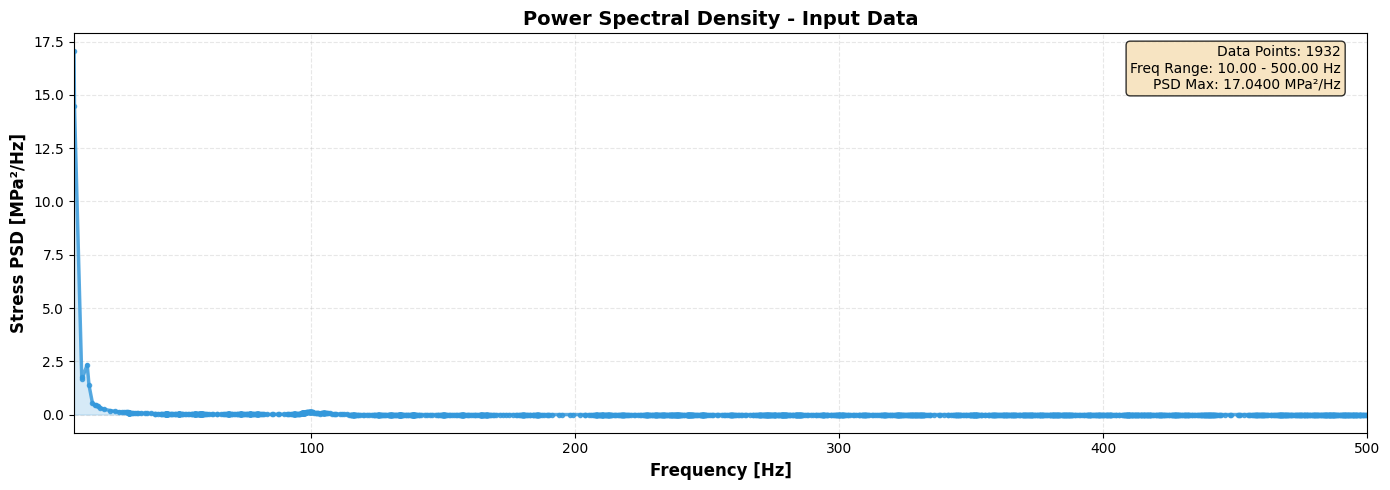

In [4]:
# Plot Power Spectral Density
def plot_psd():
    try:
        if 'freq' not in globals() or 'psd' not in globals():
            print('⚠️  No data loaded yet. Please load data from the GUI above first.')
            return
        
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(freq, psd, linewidth=2.5, color='#3498db', marker='o', markersize=3, alpha=0.8)
        ax.fill_between(freq, psd, alpha=0.2, color='#3498db')
        
        ax.set_xlabel('Frequency [Hz]', fontsize=12, fontweight='bold')
        ax.set_ylabel('Stress PSD [MPa²/Hz]', fontsize=12, fontweight='bold')
        ax.set_title('Power Spectral Density - Input Data', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlim(freq[0], freq[-1])
        
        # Add statistics box
        stats_text = f'Data Points: {len(freq)}\nFreq Range: {freq[0]:.2f} - {freq[-1]:.2f} Hz\nPSD Max: {psd.max():.4f} MPa²/Hz'
        ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
                fontsize=10, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f'Error plotting PSD: {e}')

plot_psd()


## 4. Damage Distribution Analysis

Peak Frequency (Damage): 99.48 Hz
80% Damage Bandwidth: 486.49 Hz


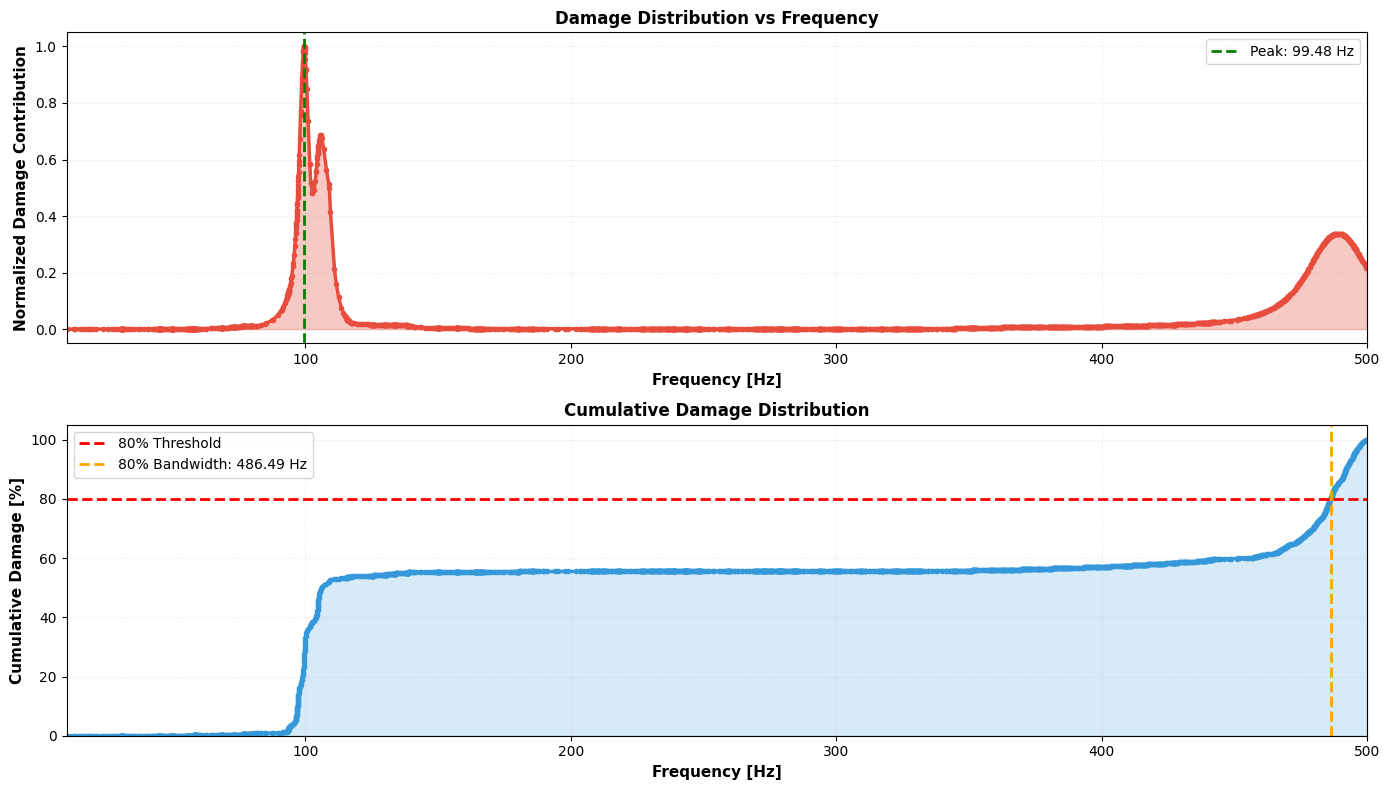

In [5]:
# Calculate and plot damage distribution
def plot_damage_analysis():
    try:
        if 'freq' not in globals() or 'psd' not in globals() or 'k' not in globals() or 'C' not in globals():
            print('⚠️  No data processed yet. Please load data from the GUI above first.')
            return
        
        # Calculate damage contribution
        damage_contribution = psd * (freq ** k) / C
        damage_contribution_normalized = damage_contribution / np.max(damage_contribution)
        
        # Cumulative damage
        cumsum_damage = np.cumsum(damage_contribution)
        cumsum_damage_percent = (cumsum_damage / cumsum_damage[-1]) * 100
        
        # Find peak and 80% bandwidth
        peak_idx = np.argmax(damage_contribution)
        peak_frequency = freq[peak_idx]
        idx_80_percent = np.where(cumsum_damage_percent >= 80)[0][0]
        f_80_percent = freq[idx_80_percent]
        
        print(f'Peak Frequency (Damage): {peak_frequency:.2f} Hz')
        print(f'80% Damage Bandwidth: {f_80_percent:.2f} Hz')
        
        # Plot
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
        
        # Plot 1: Damage Distribution
        ax1.fill_between(freq, damage_contribution_normalized, alpha=0.3, color='#e74c3c')
        ax1.plot(freq, damage_contribution_normalized, color='#e74c3c', linewidth=2.5, marker='o', markersize=3)
        ax1.axvline(peak_frequency, color='green', linestyle='--', linewidth=2, label=f'Peak: {peak_frequency:.2f} Hz')
        ax1.set_xlabel('Frequency [Hz]', fontsize=11, fontweight='bold')
        ax1.set_ylabel('Normalized Damage Contribution', fontsize=11, fontweight='bold')
        ax1.set_title('Damage Distribution vs Frequency', fontsize=12, fontweight='bold')
        ax1.grid(True, alpha=0.3, linestyle=':')
        ax1.legend(fontsize=10)
        ax1.set_xlim(freq[0], freq[-1])
        
        # Plot 2: Cumulative Damage
        ax2.plot(freq, cumsum_damage_percent, color='#3498db', linewidth=2.5, marker='o', markersize=3)
        ax2.axhline(80, color='red', linestyle='--', linewidth=2, label='80% Threshold')
        ax2.axvline(f_80_percent, color='orange', linestyle='--', linewidth=2, label=f'80% Bandwidth: {f_80_percent:.2f} Hz')
        ax2.fill_between(freq, 0, cumsum_damage_percent, alpha=0.2, color='#3498db')
        ax2.set_xlabel('Frequency [Hz]', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Cumulative Damage [%]', fontsize=11, fontweight='bold')
        ax2.set_title('Cumulative Damage Distribution', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3, linestyle=':')
        ax2.legend(fontsize=10)
        ax2.set_xlim(freq[0], freq[-1])
        ax2.set_ylim(0, 105)
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f'Error in damage analysis: {e}')

plot_damage_analysis()


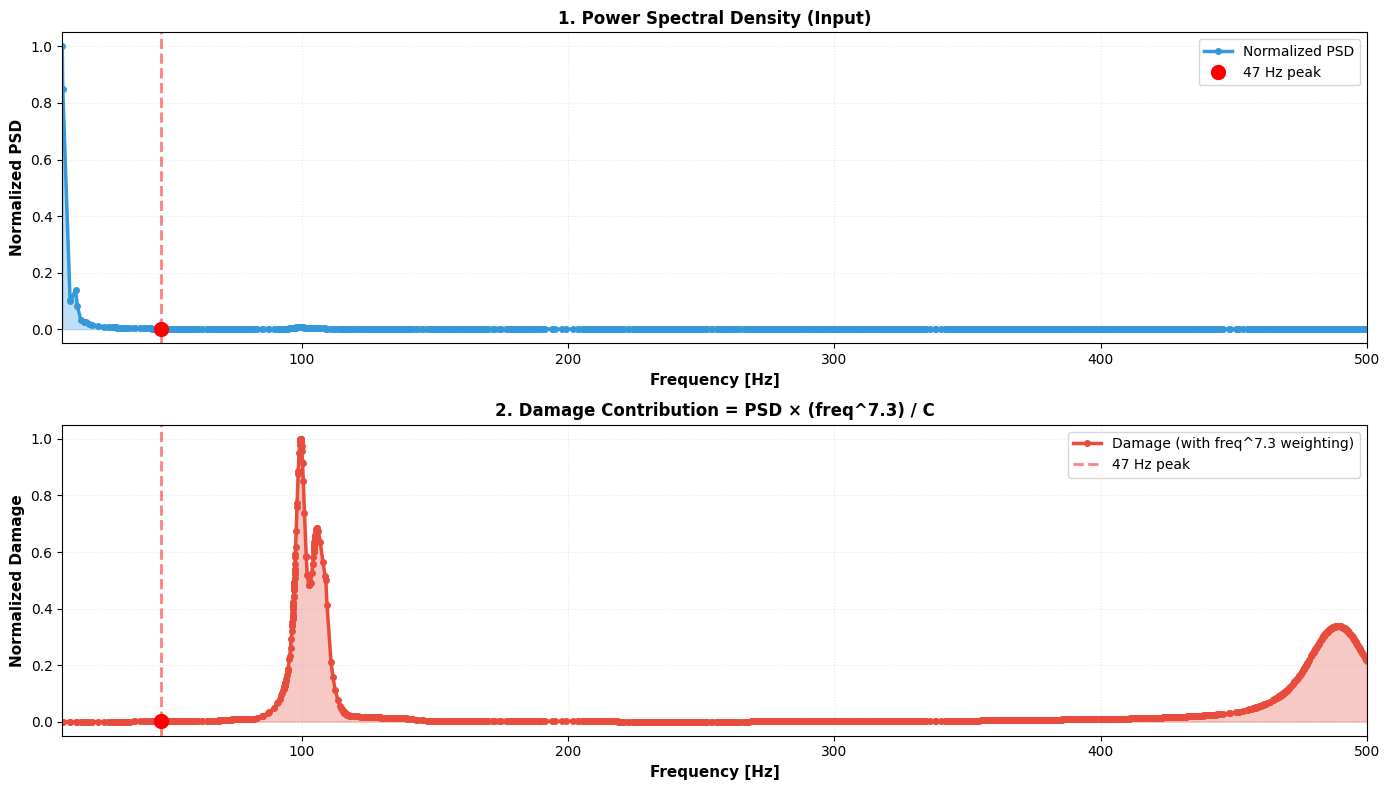


📊 EXPLANATION:
The 47 Hz peak is visible in PSD but lower in damage contribution because:
  • Damage depends on PSD × (frequency^7.3)
  • Lower frequencies are suppressed by the frequency weighting
  • 47 Hz has much less weight than higher frequency peaks
  • Example: 100 Hz contributes (100/47)^7.3 = 247.6x more than 47 Hz (same PSD)


In [6]:
# Compare PSD vs Damage Contribution
def compare_psd_vs_damage():
    try:
        if 'freq' not in globals() or 'psd' not in globals() or 'k' not in globals() or 'C' not in globals():
            print('⚠️  No data processed yet. Please load data from the GUI above first.')
            return
        
        # Calculate damage contribution
        damage_contribution = psd * (freq ** k) / C
        
        # Normalize both for comparison
        psd_norm = psd / np.max(psd)
        damage_norm = damage_contribution / np.max(damage_contribution)
        
        # Create comparison plot
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
        
        # Plot 1: PSD
        ax1.fill_between(freq, psd_norm, alpha=0.3, color='#3498db')
        ax1.plot(freq, psd_norm, color='#3498db', linewidth=2.5, marker='o', markersize=4, label='Normalized PSD')
        ax1.set_xlabel('Frequency [Hz]', fontsize=11, fontweight='bold')
        ax1.set_ylabel('Normalized PSD', fontsize=11, fontweight='bold')
        ax1.set_title('1. Power Spectral Density (Input)', fontsize=12, fontweight='bold')
        ax1.grid(True, alpha=0.3, linestyle=':')
        ax1.legend(fontsize=10)
        ax1.set_xlim(freq[0], freq[-1])
        
        # Mark 47 Hz if in range
        if freq[0] <= 47 <= freq[-1]:
            idx_47 = np.argmin(np.abs(freq - 47))
            ax1.axvline(47, color='red', linestyle='--', linewidth=2, alpha=0.5)
            ax1.plot(47, psd_norm[idx_47], 'ro', markersize=10, label='47 Hz peak')
            ax1.legend(fontsize=10)
        
        # Plot 2: Damage Contribution (with frequency weighting)
        ax2.fill_between(freq, damage_norm, alpha=0.3, color='#e74c3c')
        ax2.plot(freq, damage_norm, color='#e74c3c', linewidth=2.5, marker='o', markersize=4, label=f'Damage (with freq^{k} weighting)')
        ax2.set_xlabel('Frequency [Hz]', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Normalized Damage', fontsize=11, fontweight='bold')
        ax2.set_title(f'2. Damage Contribution = PSD × (freq^{k}) / C', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3, linestyle=':')
        ax2.legend(fontsize=10)
        ax2.set_xlim(freq[0], freq[-1])
        
        # Mark 47 Hz if in range
        if freq[0] <= 47 <= freq[-1]:
            idx_47 = np.argmin(np.abs(freq - 47))
            ax2.axvline(47, color='red', linestyle='--', linewidth=2, alpha=0.5, label='47 Hz peak')
            ax2.plot(47, damage_norm[idx_47], 'ro', markersize=10)
            ax2.legend(fontsize=10)
        
        plt.tight_layout()
        plt.show()
        
        print('\n📊 EXPLANATION:')
        print(f'The 47 Hz peak is visible in PSD but lower in damage contribution because:')
        print(f'  • Damage depends on PSD × (frequency^{k})')
        print(f'  • Lower frequencies are suppressed by the frequency weighting')
        print(f'  • 47 Hz has much less weight than higher frequency peaks')
        print(f'  • Example: 100 Hz contributes (100/47)^{k} = {(100/47)**k:.1f}x more than 47 Hz (same PSD)')
        
    except Exception as e:
        print(f'Error in comparison: {e}')

compare_psd_vs_damage()


## 5. Pass/Fail Analysis & Results Summary

In [7]:
# Display Pass/Fail Analysis
def show_results():
    try:
        if 'results' not in globals() or 'test_duration_seconds' not in globals():
            print('⚠️  No data processed yet. Please load data from the GUI above first.')
            return
        
        print('='*85)
        print('COMPONENT RELIABILITY ASSESSMENT')
        print('='*85)
        print(f'{"Method":<30} {"Fatigue Life":>18} {"Status":>15} {"Safety Factor":>15}')
        print('-'*85)
        
        pass_count = 0
        fail_count = 0
        
        for method, life in sorted(results.items(), key=lambda x: x[1], reverse=True):
            if life >= test_duration_seconds:
                status = '✓ PASS'
                pass_count += 1
            else:
                status = '✗ FAIL'
                fail_count += 1
            
            safety_factor = life / test_duration_seconds
            print(f'{method:<30} {life:>15.2f} s   {status:>15} {safety_factor:>14.2f}x')
        
        print('='*85)
        print(f'\nSUMMARY:')
        print(f'  Total methods: {len(results)}')
        print(f'  PASS (✓): {pass_count} ({100*pass_count/len(results):.1f}%)')
        print(f'  FAIL (✗): {fail_count} ({100*fail_count/len(results):.1f}%)')
        print(f'\n  Max Life: {max(results.values()):.2f} s')
        print(f'  Min Life: {min(results.values()):.2f} s')
        print(f'  Mean Life: {np.mean(list(results.values())):.2f} s')
        print(f'\n  Best SF: {max(safety_factors.values()):.2f}x')
        print(f'  Worst SF: {min(safety_factors.values()):.2f}x')
        print('='*85)
        
    except Exception as e:
        print(f'Error displaying results: {e}')

show_results()


⚠️  No data processed yet. Please load data from the GUI above first.


## 6. Export Results to CSV

In [8]:
# Export results to CSV
def export_results():
    try:
        if 'results' not in globals() or 'file_basename' not in globals():
            print('⚠️  No data processed yet. Please load data from the GUI above first.')
            return
        
        os.makedirs('data', exist_ok=True)
        
        # Simple results CSV
        results_df = pd.DataFrame({
            'Method': list(results.keys()),
            'Fatigue Life [seconds]': list(results.values())
        })
        results_df = results_df.sort_values('Fatigue Life [seconds]', ascending=False).reset_index(drop=True)
        
        output_file1 = f'data/{file_basename}_fatigue_results.csv'
        results_df.to_csv(output_file1, index=False)
        print(f'✓ Results exported: {output_file1}')
        
        # Detailed results with validation
        results_detailed_df = pd.DataFrame({
            'Method': list(results.keys()),
            'Fatigue Life [seconds]': list(results.values()),
            'Safety Factor': [safety_factors[m] for m in results.keys()],
            'Test Duration [seconds]': test_duration_seconds,
            'Status': ['PASS' if results[m] >= test_duration_seconds else 'FAIL' for m in results.keys()]
        })
        results_detailed_df = results_detailed_df.sort_values('Fatigue Life [seconds]', ascending=False).reset_index(drop=True)
        
        output_file2 = f'data/{file_basename}_fatigue_results_with_validation.csv'
        results_detailed_df.to_csv(output_file2, index=False)
        print(f'✓ Detailed results exported: {output_file2}')
        
        print('\n📊 CSV Files created successfully in data/ folder')
        
    except Exception as e:
        print(f'Error exporting results: {e}')

export_results()


⚠️  No data processed yet. Please load data from the GUI above first.


### 7. Executive summary

✅ Executive Summary Image saved: data/Mounting_pad2_fatigue_analysis_summary.png


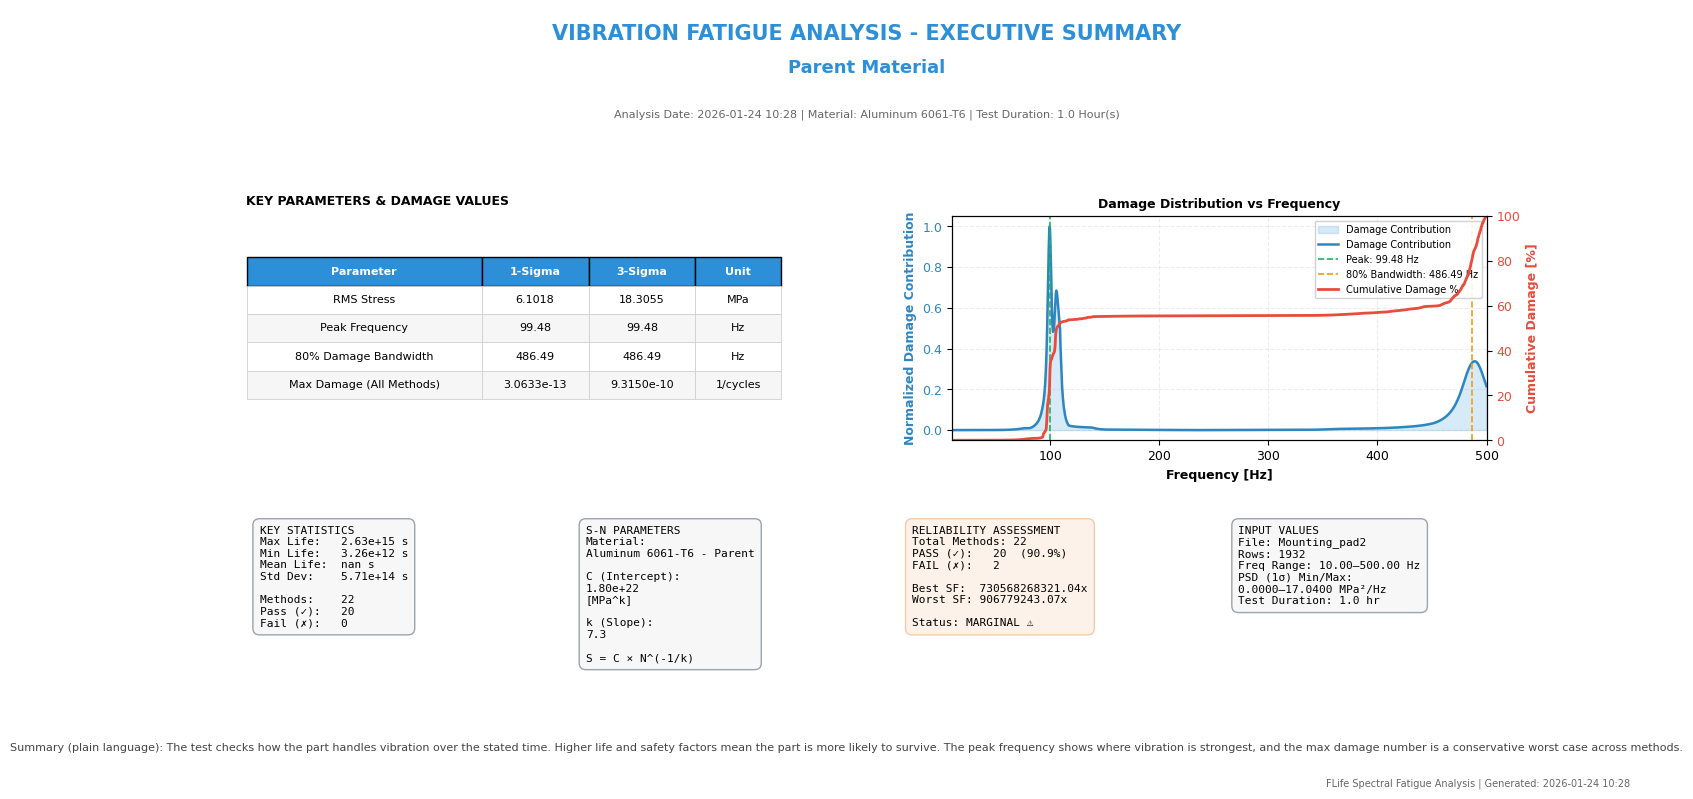

In [16]:
# Generate Executive Summary Image (Report-Ready Layout)
def generate_executive_summary():
    try:
        if 'freq' not in globals() or 'psd' not in globals() or 'results_1sigma' not in globals():
            print('⚠️  No data processed yet. Please load data from the GUI above first.')
            return

        from scipy.signal import find_peaks
        from datetime import datetime

        # --- Figure setup (report-ready) ---
        plt.rcParams.update({
            'font.size': 9,
            'font.family': 'DejaVu Sans',
            'axes.titlesize': 10,
            'axes.labelsize': 9
        })
        fig = plt.figure(figsize=(16, 9), facecolor='white')
        gs = fig.add_gridspec(nrows=3, ncols=2, height_ratios=[0.7, 1.2, 1.0], wspace=0.32, hspace=0.42)

        # Header
        ax_header = fig.add_subplot(gs[0, :])
        ax_header.axis('off')
        title_color = '#2c8fd8'
        ax_header.text(0.5, 0.82, 'VIBRATION FATIGUE ANALYSIS - EXECUTIVE SUMMARY',
                       ha='center', va='center', fontsize=15, fontweight='bold', color=title_color)
        ax_header.text(0.5, 0.56, 'Parent Material',
                       ha='center', va='center', fontsize=13, fontweight='bold', color=title_color)
        analysis_date = datetime.now().strftime('%Y-%m-%d %H:%M')
        subtitle = f'Analysis Date: {analysis_date} | Material: Aluminum 6061-T6 | Test Duration: {test_duration_input.value} Hour(s)'
        ax_header.text(0.5, 0.20, subtitle, ha='center', va='center', fontsize=8, color='#666')

        # Calculations
        rms_stress_1s = np.sqrt(sd.moments[0])
        rms_stress_3s = np.sqrt(sd_3sigma.moments[0])
        damage_contribution = psd * (freq ** k) / C
        damage_contribution_norm = damage_contribution / np.max(damage_contribution)
        cumsum_damage = np.cumsum(damage_contribution)
        cumsum_damage_percent = (cumsum_damage / cumsum_damage[-1]) * 100
        peak_idx = np.argmax(damage_contribution)
        peak_frequency = freq[peak_idx]
        idx_80_percent = np.where(cumsum_damage_percent >= 80)[0][0]
        f_80_percent = freq[idx_80_percent]
        max_damage_1s = max(damage_1sigma.values()) if 'damage_1sigma' in globals() else np.nan
        max_damage_3s = max(damage_3sigma.values()) if 'damage_3sigma' in globals() else np.nan

        # Table (left) - include 1σ and 3σ
        ax_table = fig.add_subplot(gs[1, 0])
        ax_table.axis('off')
        ax_table.text(0.0, 1.05, 'KEY PARAMETERS & DAMAGE VALUES', fontsize=9, fontweight='bold')
        table_data = [
            ['Parameter', '1-Sigma', '3-Sigma', 'Unit'],
            ['RMS Stress', f'{rms_stress_1s:.4f}', f'{rms_stress_3s:.4f}', 'MPa'],
            ['Peak Frequency', f'{peak_frequency:.2f}', f'{peak_frequency:.2f}', 'Hz'],
            ['80% Damage Bandwidth', f'{f_80_percent:.2f}', f'{f_80_percent:.2f}', 'Hz'],
            ['Max Damage (All Methods)', f'{max_damage_1s:.4e}', f'{max_damage_3s:.4e}', '1/cycles']
        ]
        table = ax_table.table(cellText=table_data, cellLoc='center', loc='center', colWidths=[0.44, 0.20, 0.20, 0.16])
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1.7)
        for j in range(4):
            table[(0, j)].set_facecolor('#2c8fd8')
            table[(0, j)].set_text_props(weight='bold', color='white')
        for i in range(1, len(table_data)):
            for j in range(4):
                table[(i, j)].set_facecolor('#f6f6f6' if i % 2 == 0 else 'white')
                table[(i, j)].set_edgecolor('#d0d0d0')
                table[(i, j)].set_linewidth(0.6)

        # Plot (right)
        ax_plot = fig.add_subplot(gs[1, 1])
        ax_plot.set_title('Damage Distribution vs Frequency', fontsize=9, fontweight='bold')
        ax_plot.fill_between(freq, damage_contribution_norm, color='#5dade2', alpha=0.25, label='Damage Contribution')
        ax_plot.plot(freq, damage_contribution_norm, color='#2e86c1', linewidth=1.8, label='Damage Contribution')
        ax_plot.axvline(peak_frequency, color='#27ae60', linestyle='--', linewidth=1.2, label=f'Peak: {peak_frequency:.2f} Hz')
        ax_plot.axvline(f_80_percent, color='#f39c12', linestyle='--', linewidth=1.2, label=f'80% Bandwidth: {f_80_percent:.2f} Hz')
        ax_plot.set_xlabel('Frequency [Hz]', fontweight='bold')
        ax_plot.set_ylabel('Normalized Damage Contribution', fontweight='bold', color='#2e86c1')
        ax_plot.grid(True, alpha=0.22, linestyle='--')
        ax_plot.set_xlim(freq[0], freq[-1])
        ax_plot.tick_params(axis='y', labelcolor='#2e86c1')

        ax_plot2 = ax_plot.twinx()
        ax_plot2.plot(freq, cumsum_damage_percent, color='#e74c3c', linewidth=2, label='Cumulative Damage %')
        ax_plot2.set_ylabel('Cumulative Damage [%]', fontweight='bold', color='#e74c3c')
        ax_plot2.tick_params(axis='y', labelcolor='#e74c3c')
        ax_plot2.set_ylim(0, 100)

        lines1, labels1 = ax_plot.get_legend_handles_labels()
        lines2, labels2 = ax_plot2.get_legend_handles_labels()
        ax_plot.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='upper right', frameon=True, framealpha=0.9)

        # Bottom summary boxes (arranged together + input values)
        bottom = gs[2, :].subgridspec(1, 4, wspace=0.25)
        ax_stats = fig.add_subplot(bottom[0, 0])
        ax_sn = fig.add_subplot(bottom[0, 1])
        ax_rel = fig.add_subplot(bottom[0, 2])
        ax_input = fig.add_subplot(bottom[0, 3])
        for ax in (ax_stats, ax_sn, ax_rel, ax_input):
            ax.axis('off')

        max_life = max(results_1sigma.values())
        min_life = min(results_1sigma.values())
        mean_life = np.mean(list(results_1sigma.values()))
        std_life = np.nanstd(list(results_1sigma.values()))
        stats_text = (
            "KEY STATISTICS\n"
            f"Max Life:   {max_life:.2e} s\n"
            f"Min Life:   {min_life:.2e} s\n"
            f"Mean Life:  {mean_life:.2e} s\n"
            f"Std Dev:    {std_life:.2e} s\n\n"
            f"Methods:    {len(results_1sigma)}\n"
            f"Pass (✓):   {sum(1 for v in results_1sigma.values() if v >= test_duration_seconds)}\n"
            f"Fail (✗):   {sum(1 for v in results_1sigma.values() if v < test_duration_seconds)}"
        )
        ax_stats.text(0.05, 0.95, stats_text, va='top', fontsize=8, family='monospace',
                     bbox=dict(boxstyle='round', facecolor='#f7f7f7', edgecolor='#9aa4ad', pad=0.6))

        sn_text = (
            "S-N PARAMETERS\n"
            "Material:\n"
            "Aluminum 6061-T6 - Parent\n\n"
            f"C (Intercept):\n{C:.2e}\n[MPa^k]\n\n"
            f"k (Slope):\n{k}\n\n"
            "S = C × N^(-1/k)"
        )
        ax_sn.text(0.05, 0.95, sn_text, va='top', fontsize=8, family='monospace',
                  bbox=dict(boxstyle='round', facecolor='#f7f7f7', edgecolor='#9aa4ad', pad=0.6))

        pass_methods = sum(1 for v in results_1sigma.values() if v >= test_duration_seconds)
        total_methods = len(results_1sigma)
        pass_pct = (pass_methods / total_methods) * 100
        best_sf = max(safety_factors_1sigma.values())
        worst_sf = min(safety_factors_1sigma.values())
        if pass_pct >= 95:
            status_text = 'ACCEPTABLE ✓'
            status_color = '#e9f7ef'
            edge_color = '#7dcea0'
        elif pass_pct >= 75:
            status_text = 'MARGINAL ⚠'
            status_color = '#fdf2e9'
            edge_color = '#f5cba7'
        else:
            status_text = 'CRITICAL ✗'
            status_color = '#fdecea'
            edge_color = '#f5b7b1'
        rel_text = (
            "RELIABILITY ASSESSMENT\n"
            f"Total Methods: {total_methods}\n"
            f"PASS (✓):   {pass_methods}  ({pass_pct:.1f}%)\n"
            f"FAIL (✗):   {total_methods - pass_methods}\n\n"
            f"Best SF:  {best_sf:.2f}x\n"
            f"Worst SF: {worst_sf:.2f}x\n\n"
            f"Status: {status_text}"
        )
        ax_rel.text(0.05, 0.95, rel_text, va='top', fontsize=8, family='monospace',
                   bbox=dict(boxstyle='round', facecolor=status_color, edgecolor=edge_color, pad=0.6))

        input_text = (
            "INPUT VALUES\n"
            f"File: {file_basename}\n"
            f"Rows: {len(freq)}\n"
            f"Freq Range: {freq[0]:.2f}–{freq[-1]:.2f} Hz\n"
            f"PSD (1σ) Min/Max:\n{psd.min():.4f}–{psd.max():.4f} MPa²/Hz\n"
            f"Test Duration: {test_duration_input.value} hr"
        )
        ax_input.text(0.05, 0.95, input_text, va='top', fontsize=8, family='monospace',
                     bbox=dict(boxstyle='round', facecolor='#f7f7f7', edgecolor='#9aa4ad', pad=0.6))

        # Layman summary below tables
        summary_text = (
            "Summary (plain language): The test checks how the part handles vibration over the stated time. "
            "Higher life and safety factors mean the part is more likely to survive. The peak frequency shows "
            "where vibration is strongest, and the max damage number is a conservative worst case across methods."
        )
        fig.text(0.5, 0.06, summary_text, ha='center', va='center', fontsize=8, color='#444')

        fig.text(0.99, 0.02, f"FLife Spectral Fatigue Analysis | Generated: {analysis_date}",
                 ha='right', va='center', fontsize=7, color='#666')

        os.makedirs('data', exist_ok=True)
        output_file = f'data/{file_basename}_fatigue_analysis_summary.png'
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f'✅ Executive Summary Image saved: {output_file}')
        plt.show()

    except Exception as e:
        print(f'Error generating executive summary: {e}')
        import traceback
        traceback.print_exc()

generate_executive_summary()